# Nível 2 — Indicadores post hoc C/IER

Pablo Rogers

In [ ]:

library(tidyverse)
library(careless)
library(gt)
library(patchwork)
library(modi)


In [ ]:

dados_importados <- read_csv2(
  "../../Data/IntermediateData/whoqol_imported.csv",
  show_col_types = FALSE
)


ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

## Definição das funções auxiliares

In [ ]:

# --- Laz.R index (Biemann et al., 2025) ---
calc_lazr <- function(x) {
  tr <- table(x[-length(x)], x[-1], useNA = "ifany")
  sum(tr^2 / rowSums(tr)) / (length(x) - 1)
}

# --- Algoritmo Kneedle (Satopaa et al., 2011) ---
dist2d <- function(a, b, c) {
  v1 <- b - c
  v2 <- a - b
  m  <- cbind(v1, v2)
  det(m) / sqrt(sum(v1 * v1))
}

kneedle <- function(values, sign) {
  start <- c(1, values[1])
  end   <- c(length(values), values[length(values)])
  which.max(lapply(seq_along(values), function(idx) {
    sign * -1 * dist2d(c(idx, values[idx]), start, end)
  }))
}


## Cálculo dos quatro indicadores

In [ ]:

lazr_vals <- apply(itens, 1, calc_lazr)

longstr_vals <- longstring(itens)

md_vals <- MDmiss(
  data = as.matrix(itens),
  center = colMeans(itens, na.rm = TRUE),
  cov = cov(itens, use = "pairwise.complete.obs")
)

irv_vals <- irv(itens, split = FALSE)


## Variáveis individuais

In [ ]:

df_indicadores <- tibble(
  ID      = id_col,
  LazR    = round(lazr_vals, 3),
  Longstr = as.integer(longstr_vals),
  MD      = round(md_vals, 3),
  IRV     = round(irv_vals, 3)
)

df_indicadores


# A tibble: 1,298 × 5
            ID  LazR Longstr    MD   IRV
         <dbl> <dbl>   <int> <dbl> <dbl>
 1 10441016017 0.388       3 49.5  1.47 
 2 10440981694 0.493       5 13.5  0.662
 3 10440601239 0.493       6 79.1  1.47 
 4 10440562981 0.569       9 27.4  1.29 
 5 10440358563 0.454       8 32.3  1.48 
 6 10440199369 0.647      10  6.94 0.945
 7 10438952564 0.444       6 39.9  0.951
 8 10438951127 0.382       3 24.2  1.06 
 9 10438633244 0.41        3 41.7  0.857
10 10438605204 0.479       5 12.2  1.09 
# ℹ 1,288 more rows

## Visualização univariada

### Laz.R

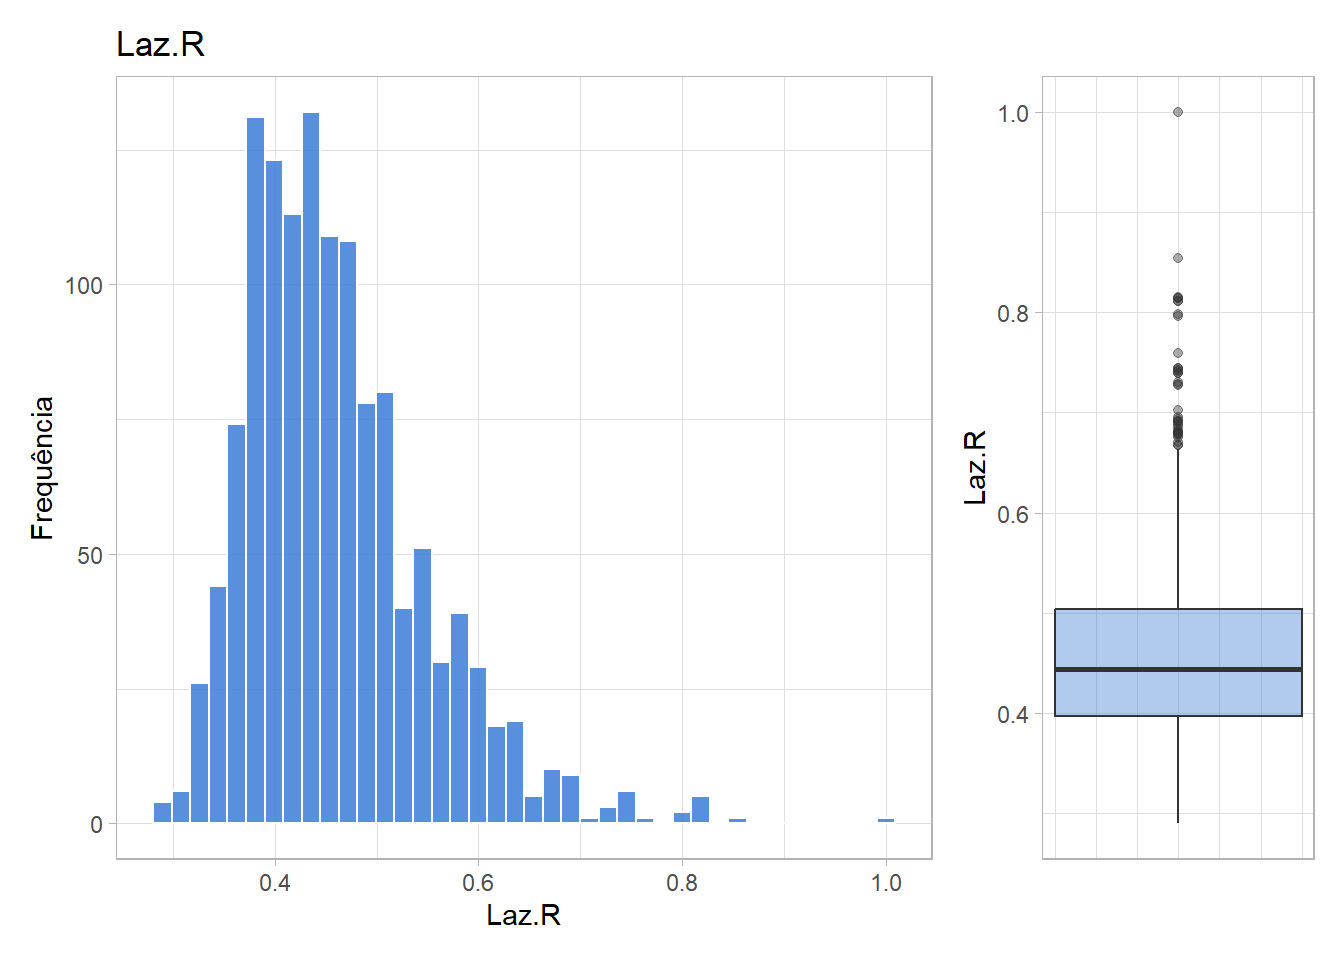

In [ ]:

p_hist_lazr <- ggplot(df_indicadores, aes(x = LazR)) +
  geom_histogram(bins = 40, fill = "#3B7DD8", color = "white", alpha = 0.85) +
  labs(title = "Laz.R", x = "Laz.R", y = "Frequência") +
  theme_light()

p_box_lazr <- ggplot(df_indicadores, aes(y = LazR)) +
  geom_boxplot(fill = "#3B7DD8", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "Laz.R") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_lazr + p_box_lazr + plot_layout(widths = c(3, 1))


### Longstring

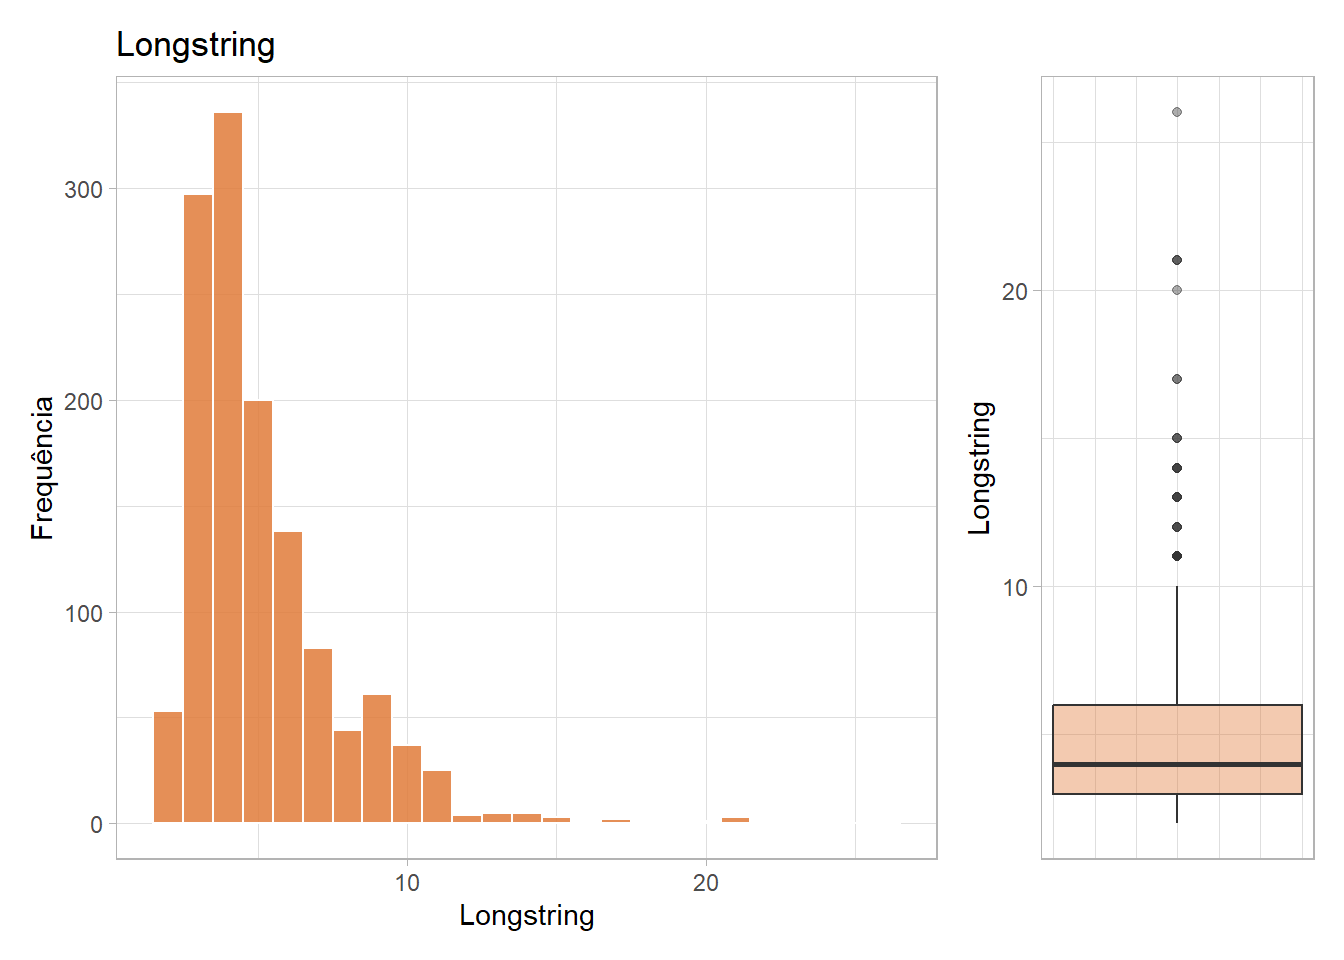

In [ ]:

p_hist_ls <- ggplot(df_indicadores, aes(x = Longstr)) +
  geom_histogram(binwidth = 1, fill = "#E07B39", color = "white", alpha = 0.85) +
  labs(title = "Longstring", x = "Longstring", y = "Frequência") +
  theme_light()

p_box_ls <- ggplot(df_indicadores, aes(y = Longstr)) +
  geom_boxplot(fill = "#E07B39", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "Longstring") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_ls + p_box_ls + plot_layout(widths = c(3, 1))


### Mahalanobis Distance

(`stat_bin()`).

(`stat_boxplot()`).

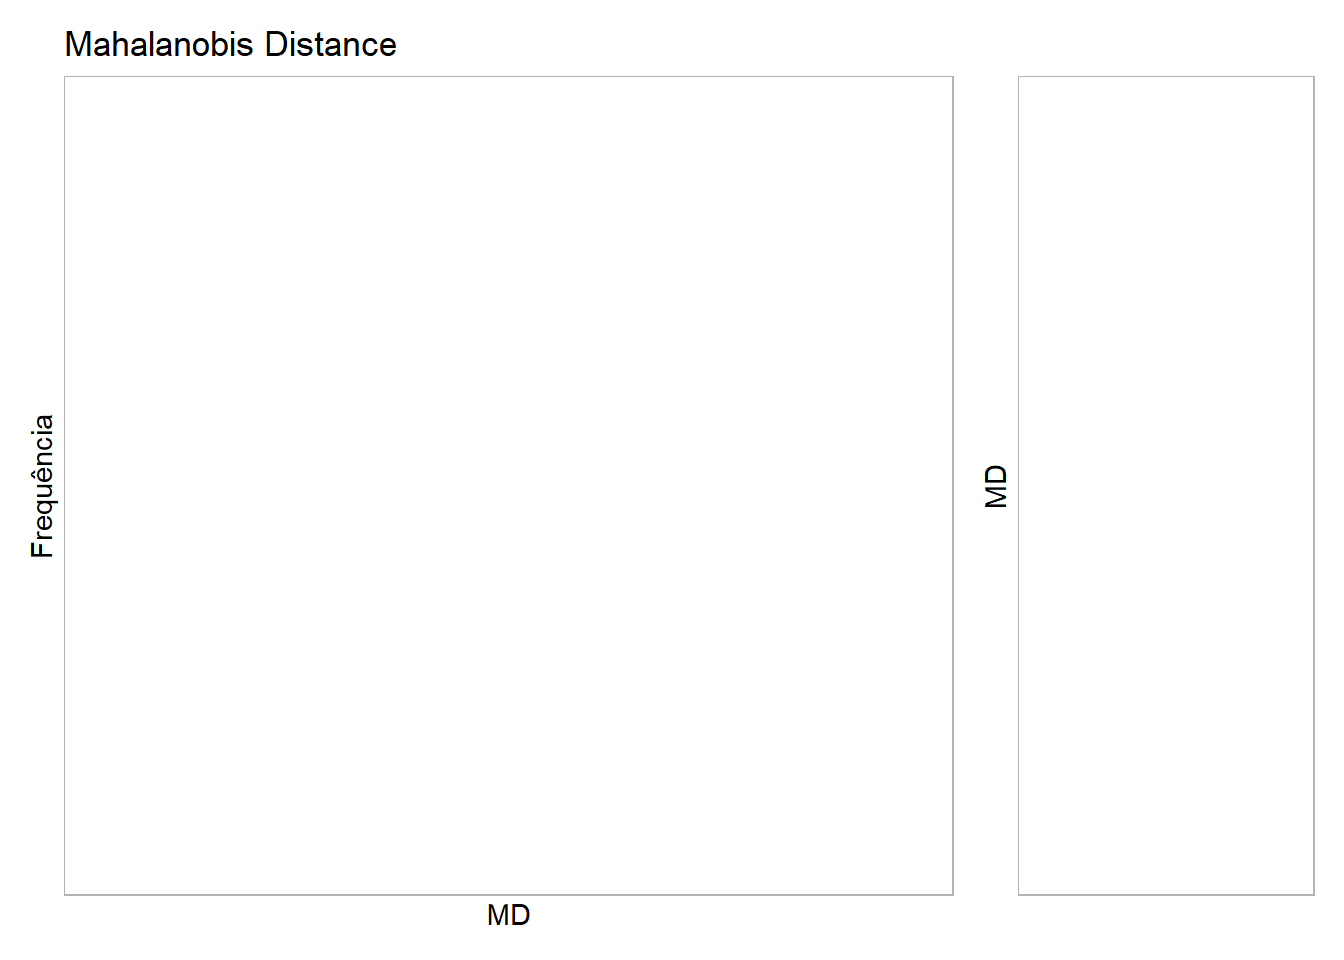

In [ ]:

p_hist_md <- ggplot(df_indicadores, aes(x = MD)) +
  geom_histogram(bins = 40, fill = "#2CA02C", color = "white", alpha = 0.85) +
  labs(title = "Mahalanobis Distance", x = "MD", y = "Frequência") +
  theme_light()

p_box_md <- ggplot(df_indicadores, aes(y = MD)) +
  geom_boxplot(fill = "#2CA02C", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "MD") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_md + p_box_md + plot_layout(widths = c(3, 1))


### IRV

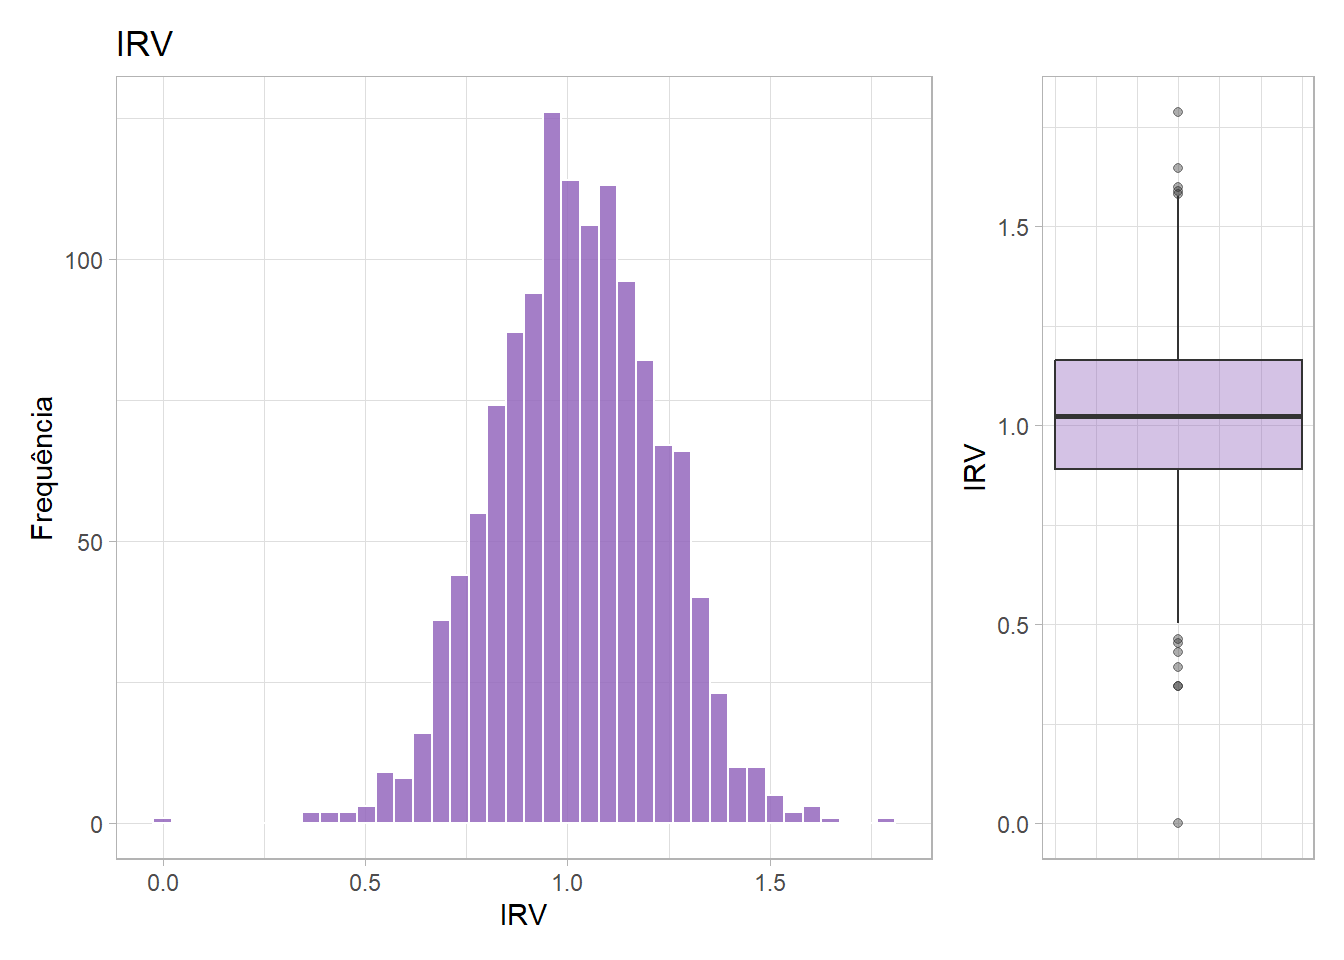

In [ ]:

p_hist_irv <- ggplot(df_indicadores, aes(x = IRV)) +
  geom_histogram(bins = 40, fill = "#9467BD", color = "white", alpha = 0.85) +
  labs(title = "IRV", x = "IRV", y = "Frequência") +
  theme_light()

p_box_irv <- ggplot(df_indicadores, aes(y = IRV)) +
  geom_boxplot(fill = "#9467BD", alpha = 0.4, width = 0.3) +
  labs(title = NULL, y = "IRV") +
  theme_light() +
  theme(axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank())

p_hist_irv + p_box_irv + plot_layout(widths = c(3, 1))


## Pontos de corte via algoritmo Kneedle

In [ ]:

calc_kneedle <- function(x, sign_val) {
  x_sorted <- sort(x, decreasing = TRUE, na.last = NA)
  n <- length(x_sorted)
  if (n == 0 || sum(x_sorted, na.rm = TRUE) == 0) {
    return(list(pct = NA_real_, crit = NA_real_, sorted = x_sorted))
  }
  pos <- kneedle(x_sorted, sign_val)
  pct <- pos / n
  crit <- quantile(x_sorted, probs = 1 - pct, na.rm = TRUE, names = FALSE)
  list(pct = pct, crit = crit, sorted = x_sorted)
}

kn_lazr     <- calc_kneedle(df_indicadores$LazR, -1)
kn_longstr  <- calc_kneedle(df_indicadores$Longstr, -1)
kn_md       <- calc_kneedle(df_indicadores$MD, -1)
kn_irv_high <- calc_kneedle(df_indicadores$IRV, -1)
kn_irv_low  <- calc_kneedle(df_indicadores$IRV, +1)

tab_cutoffs <- tibble(
  Indicador       = c("Laz.R", "Longstring", "MD",
                       "IRV (high end)", "IRV (low end)"),
  `Valor crítico` = round(c(kn_lazr$crit, kn_longstr$crit, kn_md$crit,
                             kn_irv_high$crit, kn_irv_low$crit), 2),
  `% suspeitos`   = round(c(
    kn_lazr$pct, kn_longstr$pct, kn_md$pct,
    kn_irv_high$pct, 1 - kn_irv_low$pct
  ) * 100, 1)
)

tab_cutoffs |>
  knitr::kable(
    caption = "Pontos de corte — Algoritmo Kneedle (Biemann et al., 2025)",
    digits  = c(0, 2, 1)
  )


  Indicador          Valor crítico   \% suspeitos
  ---------------- --------------- --------------
  Laz.R                       0.60            6.8
  Longstring                  7.00           14.8
  MD                            NA             NA
  IRV (high end)              1.34            4.9
  IRV (low end)               0.69            3.8

  : Pontos de corte --- Algoritmo Kneedle (Biemann et al., 2025)


## Flags de C/IER

In [ ]:

df_flags <- df_indicadores |>
  mutate(
    LazR_FLAG     = if_else(LazR    >= kn_lazr$crit,      1L, 0L),
    Longstr_FLAG  = if_else(Longstr >  kn_longstr$crit,   1L, 0L),
    MD_FLAG       = if_else(MD      >= kn_md$crit,        1L, 0L),
    IRV_high_FLAG = if_else(IRV     >= kn_irv_high$crit,  1L, 0L),
    IRV_low_FLAG  = if_else(IRV     <= kn_irv_low$crit,   1L, 0L)
  )

df_flags


# A tibble: 1,298 × 10
            ID  LazR Longstr    MD   IRV LazR_FLAG Longstr_FLAG MD_FLAG
         <dbl> <dbl>   <int> <dbl> <dbl>     <int>        <int>   <int>
 1 10441016017 0.388       3    NA 1.47          0            0      NA
 2 10440981694 0.493       5    NA 0.662         0            0      NA
 3 10440601239 0.493       6    NA 1.47          0            0      NA
 4 10440562981 0.569       9    NA 1.29          0            1      NA
 5 10440358563 0.454       8    NA 1.48          0            1      NA
 6 10440199369 0.647      10    NA 0.945         1            1      NA
 7 10438952564 0.444       6    NA 0.951         0            0      NA
 8 10438951127 0.382       3    NA 1.06          0            0      NA
 9 10438633244 0.41        3    NA 0.857         0            0      NA
10 10438605204 0.479       5    NA 1.09          0            0      NA
# ℹ 1,288 more rows
# ℹ 2 more variables: IRV_high_FLAG <int>, IRV_low_FLAG <int>

### Resumo das flags

In [ ]:

df_flags |>
  summarise(
    across(ends_with("_FLAG"), list(
      n_suspeitos   = \(x) sum(x, na.rm = TRUE),
      pct_suspeitos = \(x) round(mean(x, na.rm = TRUE) * 100, 1)
    ))
  ) |>
  pivot_longer(everything(),
               names_to = c("Indicador", ".value"),
               names_pattern = "(.+)_(n_suspeitos|pct_suspeitos)") |>
  knitr::kable(
    caption  = "Resumo de respondentes sinalizados como C/IER",
    col.names = c("Indicador", "N suspeitos", "% suspeitos")
  )


  Indicador         N suspeitos   \% suspeitos
  --------------- ------------- --------------
  LazR_FLAG                  91            7.0
  Longstr_FLAG              191           14.7
  MD_FLAG                     0            NaN
  IRV_high_FLAG              66            5.1
  IRV_low_FLAG               49            3.8

  : Resumo de respondentes sinalizados como C/IER


In [ ]:

dados_screened <- dados_importados |>
  select(ID, Q1:Q26) |>
  left_join(df_flags, by = "ID")

write_csv2(dados_screened, "../../Data/IntermediateData/whoqol_screened.csv")
